In [1]:
import json
import time
import pyvisa
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
from pathlib import Path
import os
import sys
from datetime import datetime
import matplotlib.colors as mcolors


In [2]:
rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

noise_source_bias = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        noise_source_bias = rm.open_resource(instrument) 
        break
print(noise_source_bias.query('*IDN?').strip())

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

qubit_flux_bias = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        qubit_flux_bias = rm.open_resource(instrument) 
        break

WARM_SWITCHES_IP_ADDRESS = '169.254.12.12'
PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'

def send_url_command(ip_address, cmd_to_send):
    url = f"http://{ip_address}/:{cmd_to_send}"
    for attempt in range(3):
        try:
            with urlopen(url, timeout=3) as response:
                pte_return = response.read()
            if len(pte_return) > 100:
                print(f"Error, command not found: {url}")
                return "Invalid Command!"
            return pte_return.decode('utf-8').strip()
        except Exception as network_err:
            if attempt == 2:
                print(f"Hardware Network Warning: No response from {ip_address}. Error: {network_err}")
                return "No Response!"
            time.sleep(0.05)
            
def set_warm_switches_by_ip(ip_address, A, B, C, D):
    state_byte = 128 + int(A-1) + (2 * int(B-1)) + (4 * int(C-1)) + (8 * int(D-1))
    return send_url_command(ip_address, f"SETP={state_byte}")

def set_programmable_attenuator(attenuation):
    send_url_command(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS, f"SETATT={attenuation}")

def get_switch_state(ip_address):
    raw_reply = send_url_command(ip_address, "SWPORT?")
    if any(err in raw_reply for err in ["Error", "No Response"]):
        return {"status": "Disconnected or Error", "raw_reply": raw_reply}
    try:
        state_byte = int(raw_reply.strip())
        working_value = state_byte - 128
        return {
            "status": "Online",
            "raw_byte": state_byte,
            "A": working_value % 2 + 1,
            "B": (working_value // 2) % 2 + 1,
            "C": (working_value // 4) % 2 + 1,
            "D": (working_value // 8) % 16 + 1
        }
    except ValueError:
        return {"status": f"Malformed hardware response: {raw_reply}"}

def get_attenuator_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None
vna.go_to_local()

Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


In [4]:
set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 1) #vna to fridge to spectrum analyzer

'1'

In [137]:
vna_noise_power_scan = {}

vna_noise_power_scan['cw_frequency'] = 5.58e9

vna_noise_power_scan['power_sweep_start'] = -50
vna_noise_power_scan['power_sweep_stop'] = -25
vna_noise_power_scan['power_sweep_number_of_points'] = 21

vna_noise_power_scan['power'] = np.linspace(vna_noise_power_scan['power_sweep_start'], vna_noise_power_scan['power_sweep_stop'], vna_noise_power_scan['power_sweep_number_of_points'])
vna_noise_power_scan['power'] = np.round(vna_noise_power_scan['power']*100)/100
vna_noise_power_scan['power'] = vna_noise_power_scan['power'].tolist()

vna_noise_power_scan['noise_sweep_start'] = -0.2
vna_noise_power_scan['noise_sweep_stop'] = 0.2
vna_noise_power_scan['noise_sweep_number_of_points'] = 41

vna_noise_power_scan['noise_bias'] = np.linspace(vna_noise_power_scan['noise_sweep_start'], vna_noise_power_scan['noise_sweep_stop'], vna_noise_power_scan['noise_sweep_number_of_points'])
vna_noise_power_scan['noise_bias'] = np.round(vna_noise_power_scan['noise_bias']*1000)/1000
vna_noise_power_scan['noise_bias'] = vna_noise_power_scan['noise_bias'].tolist()


vna_noise_power_scan['rbw'] = 3e5
vna_noise_power_scan['vbw'] = 300


try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
vna_noise_power_scan['timestamp'] = int(now.timestamp())
vna_noise_power_scan['date'] = now.strftime("%d-%m-%Y")
vna_noise_power_scan['time'] = now.strftime("%H:%M:%S")
vna_noise_power_scan['timezone'] = now.tzname()
vna_noise_power_scan['temperature'] = '0.011'
vna_noise_power_scan['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + vna_noise_power_scan['date'] + " Plots\n\n")

vna_noise_power_scan['programmable_attenuator'] = get_attenuator_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)


spa.write(':SENS:BAND ' + str(vna_noise_power_scan['rbw']))
spa.write(':SENS:BAND:VID ' + str(vna_noise_power_scan['vbw']))
spa.write(":UNIT:POW W")

vna_noise_power_scan['ref_level'] = float(spa.query("DISP:WIND:TRAC:Y:RLEV?").strip())

vna_noise_power_scan['unit'] = spa.query(":UNIT:POW?").strip()

vna.write('SENSe1:SWEep:TYPE CW')
vna.write('SENSe1:FREQuency:CW ' + str(vna_noise_power_scan['cw_frequency']) + ' HZ')

spa.write('SENSe:FREQuency:SPAN 0 Hz')
spa.write('SENSe:FREQuency:CENTer ' + str(vna_noise_power_scan['cw_frequency']) + ' Hz')

vna_noise_power_scan['spa_number_of_points'] = int(spa.query(':SENS1:SWEep:POINts?'))


vna_noise_power_scan['noise'] = []
vna_noise_power_scan['noise_sigma'] = []

noise_source_bias.write("FUNC DC")
noise_source_bias.write("VOLT:OFFS 0.0")

for vna_power in vna_noise_power_scan['power']:
    noise_scan = []
    noise_scan_sigma = []
    vna.write('SOURce1:POWer ' +  str(vna_power))
    for noise_bias in vna_noise_power_scan['noise_bias']:
        print(f"VNA Power: {vna_power} dBm | V: {noise_bias} V   ", end="\r", flush=True)
        noise_source_bias.write("VOLT:OFFS " + str(noise_bias))
        try:
            spa.write("INIT:IMM")
            spa.query("*OPC?")
            trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
            noise_scan.append(np.mean(trace))
            noise_scan_sigma.append(np.std(trace))
        except pyvisa.errors.VisaIOError:
            spa.clear()
            noise_scan.append(np.nan)
            noise_scan_sigma.append(np.nan)
        time.sleep(0.05)
    vna_noise_power_scan['noise'].append(noise_scan)
    vna_noise_power_scan['noise_sigma'].append(noise_scan_sigma)

noise_source_bias.write("FUNC DC")
noise_source_bias.write("VOLT:OFFS 0.0")
vna.write('SOURce1:POWer -30')
print('scan complete')
now = datetime.now().astimezone()
vna_noise_power_scan['finish_time'] = int(now.timestamp())
vna_noise_power_scan['sweep_time'] = vna_noise_power_scan['finish_time'] - vna_noise_power_scan['start_time']
print(str(vna_noise_power_scan['sweep_time']) + " seconds sweep time")

sweep_file_name = f"{vna_noise_power_scan['timestamp']}-vna-noise-power-scan.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(vna_noise_power_scan, f, indent=4)



scan complete5.0 dBm | V: 0.2 V      
1122 seconds sweep time


Text(0, 0.5, 'Measured Output Noise Power [W]')

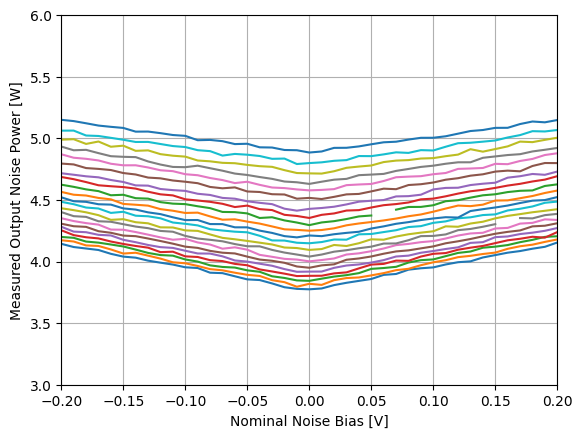

In [133]:
for index in np.arange(len(vna_noise_power_scan['noise'])):
    plt.plot(vna_noise_power_scan['noise_bias'],np.array(vna_noise_power_scan['noise'][index])/1e-9)
plt.xlim(vna_noise_power_scan['noise_bias'][0],vna_noise_power_scan['noise_bias'][-1])
plt.grid()
plt.ylim(3,6)
plt.xlabel('Nominal Noise Bias [V]')
plt.ylabel('Measured Output Noise Power [W]')

Text(0, 0.5, 'Measured Output Noise Power [W]')

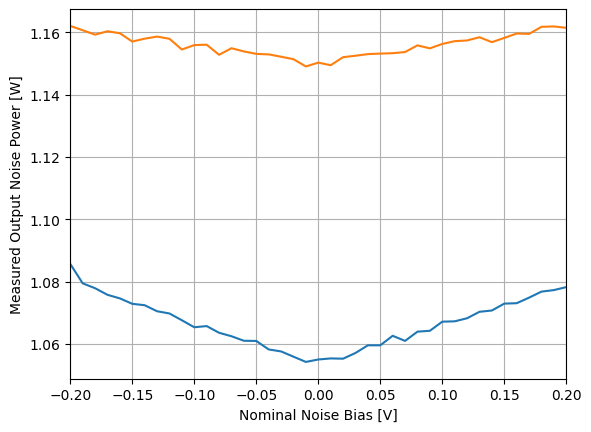

In [136]:
for index in np.arange(len(vna_noise_power_scan['noise'])):
    plt.plot(vna_noise_power_scan['noise_bias'],np.array(vna_noise_power_scan['noise'][index])/1e-9)
plt.xlim(vna_noise_power_scan['noise_bias'][0],vna_noise_power_scan['noise_bias'][-1])
plt.grid()
#plt.ylim(3,6)
plt.xlabel('Nominal Noise Bias [V]')
plt.ylabel('Measured Output Noise Power [W]')

In [97]:

noise_source_bias.write("VOLT:OFFS 0.2")
vna.write('SOURce1:POWer -10')


In [98]:
spa.write("INIT:IMM")
spa.query("*OPC?")
trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))

In [99]:
trace

array([2.89001e-08, 2.90269e-08, 2.90135e-08, 2.91340e-08, 2.90871e-08,
       2.88669e-08, 2.87674e-08, 2.86418e-08, 2.88270e-08, 2.87144e-08,
       2.86154e-08, 2.85496e-08, 2.84381e-08, 2.85233e-08, 2.84577e-08,
       2.89401e-08, 2.87541e-08, 2.86682e-08, 2.86022e-08, 2.88935e-08,
       2.90335e-08, 2.91005e-08, 2.87806e-08, 2.86088e-08, 2.86352e-08,
       2.88138e-08, 2.87806e-08, 2.87409e-08, 2.87343e-08, 2.87475e-08,
       2.87541e-08, 2.86616e-08, 2.84643e-08, 2.86022e-08, 2.85102e-08,
       2.87806e-08, 2.87276e-08, 2.89534e-08, 2.93022e-08, 2.91072e-08,
       2.88536e-08, 2.87343e-08, 2.88470e-08, 2.89668e-08, 2.89068e-08,
       2.90536e-08, 2.91273e-08, 2.90001e-08, 2.86352e-08, 2.85891e-08,
       2.87210e-08, 2.89401e-08, 2.90001e-08, 2.91206e-08, 2.88669e-08,
       2.87409e-08, 2.84446e-08, 2.86484e-08, 2.86616e-08, 2.86814e-08,
       2.90402e-08, 2.91541e-08, 2.90670e-08, 2.92685e-08, 2.91206e-08,
       2.93495e-08, 2.91676e-08, 2.87939e-08, 2.91340e-08, 2.919

In [94]:
float(spa.query("DISP:WIND:TRAC:Y:RLEV?").strip())

5e-08

In [96]:
spa.write("DISP:WIND:TRAC:Y:RLEV 1.0E-07")

31

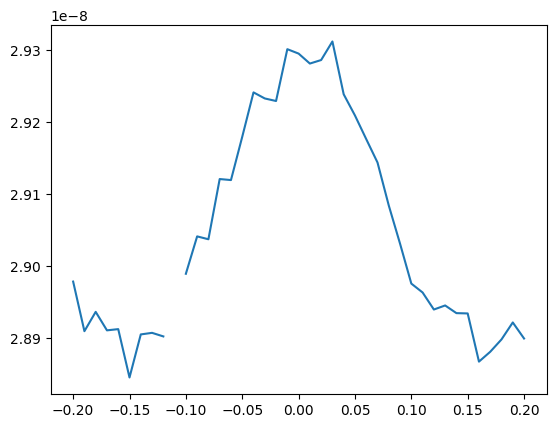

In [103]:
plt.plot(vna_noise_power_scan['noise_bias'],vna_noise_power_scan['noise'][20])

In [114]:
vna_noise_power_scan['power'][4]

-26.0

Text(0, 0.5, 'Measured Output Noise Power [W]')

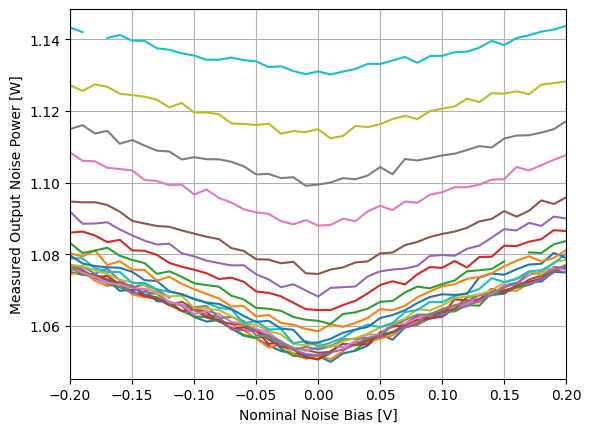

In [142]:
for index in np.arange(20):
    plt.plot(vna_noise_power_scan['noise_bias'],np.array(vna_noise_power_scan['noise'][index])/1e-9)
plt.xlim(vna_noise_power_scan['noise_bias'][0],vna_noise_power_scan['noise_bias'][-1])
plt.grid()
#plt.ylim(3,6)
plt.xlabel('Nominal Noise Bias [V]')
plt.ylabel('Measured Output Noise Power [W]')